# ETHICS Cleaning

This notebook inspects the raw Hendrycks ETHICS files, shows cleaning diagnostics,
visualizes class/split coverage, and builds the standardized `ethics.csv` / `ethics.jsonl` outputs.


In [ ]:
from __future__ import annotations

# Standard library imports
from pathlib import Path
from ast import literal_eval
import csv
import hashlib
import json
import re
import shutil

# Third-party plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import pandas with an explicit error message so the notebook fails clearly
# if the required dependency is missing.
try:
    import pandas as pd
except Exception as exc:
    raise RuntimeError("pandas is required to use this cleaning notebook.") from exc

# Used to render DataFrames nicely inside Jupyter notebooks
from IPython.display import display


# -----------------------------------------------------------------------------
# Notebook-wide display and plotting configuration
# -----------------------------------------------------------------------------
# Apply a consistent visual style for all plots in this notebook.
sns.set_theme(style="whitegrid")

# Show more columns when previewing DataFrames.
pd.set_option("display.max_columns", 50)

# Allow wider cell content before truncation in notebook display.
pd.set_option("display.max_colwidth", 120)


# -----------------------------------------------------------------------------
# Project path resolution
# -----------------------------------------------------------------------------
def find_project_root() -> Path:
    """
    Attempt to locate the project root by walking upward from the current
    working directory until a folder containing either 'Data' or 'data' is found.

    Returns:
        Path: The detected project root. If no matching parent is found,
        the current working directory is returned as a fallback.

    Why this exists:
        Notebooks are often run from different locations. This helper makes
        path handling more robust by avoiding hard-coded absolute paths.
    """
    current = Path.cwd().resolve()

    for candidate in (current, *current.parents):
        if (candidate / "Data").exists() or (candidate / "data").exists():
            return candidate

    # Fallback: use the current directory if no project-style data folder exists.
    return current


# Resolve the root of the project dynamically.
ROOT = find_project_root()

# Support either 'Data' or 'data' as the main data folder name.
DATA_ROOT = ROOT / "Data" if (ROOT / "Data").exists() else ROOT / "data"

# Raw ETHICS input directory.
RAW_DIR = DATA_ROOT / "raw/hendryicks-ethics"

# Output directory for processed ETHICS artifacts.
OUT_DIR = DATA_ROOT / "processed" / "ethics"

# Safety flag: when False, the notebook can stay in preview/inspection mode
# without writing files to disk.
SAVE_OUTPUTS = False

# Print the resolved paths so the notebook user can verify that the environment
# is pointing at the correct project directories.
print("Project root:", ROOT)
print("Raw dir:", RAW_DIR)
print("Output dir:", OUT_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)


# -----------------------------------------------------------------------------
# File and serialization helpers
# -----------------------------------------------------------------------------
def ensure_dir(path: Path) -> None:
    """
    Create a directory (and any missing parents) if it does not already exist.

    Args:
        path (Path): Directory path to create.

    Why this exists:
        Writing output files will fail if the parent directory is missing.
        This helper ensures output paths are always ready before writing.
    """
    path.mkdir(parents=True, exist_ok=True)


def normalize_for_csv(value):
    """
    Convert values into CSV-safe representations.

    Rules:
        - None becomes an empty string
        - dicts/lists become JSON strings
        - other values are returned unchanged

    Args:
        value: Any Python object intended for CSV export.

    Returns:
        A CSV-writable representation of the input.

    Why this exists:
        CSV files store plain scalar values. Complex Python objects such as
        dicts or lists must be serialized first.
    """
    if value is None:
        return ""

    if isinstance(value, (dict, list)):
        return json.dumps(value, ensure_ascii=False)

    return value


def write_jsonl(path: Path, rows) -> None:
    """
    Write an iterable of dictionaries to a JSONL file.

    Args:
        path (Path): Destination file path.
        rows: Iterable of row-like objects (typically dicts).

    Output format:
        One JSON object per line.

    Why this exists:
        JSONL is convenient for line-by-line processing, streaming, and
        preserving nested structures more naturally than CSV.
    """
    ensure_dir(path.parent)

    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def write_csv(path: Path, rows, fieldnames=None) -> None:
    """
    Write a list of dictionaries to a CSV file.

    Args:
        path (Path): Destination file path.
        rows: Iterable of dictionaries.
        fieldnames (list[str] | None): Optional explicit column order.
            If omitted, columns are inferred in first-seen order across rows.

    Behavior:
        - Creates parent directories if needed
        - Does nothing if rows is empty
        - Normalizes nested objects before writing

    Why this exists:
        This helper centralizes CSV writing logic so the notebook has one
        consistent export path for tabular outputs.
    """
    ensure_dir(path.parent)

    # Nothing to write.
    if not rows:
        return

    # Infer fieldnames if none were provided.
    if fieldnames is None:
        fieldnames = []
        seen = set()

        for row in rows:
            for key in row:
                if key not in seen:
                    seen.add(key)
                    fieldnames.append(key)

    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for row in rows:
            writer.writerow(
                {k: normalize_for_csv(row.get(k)) for k in fieldnames}
            )


# -----------------------------------------------------------------------------
# Plotting helpers
# -----------------------------------------------------------------------------
def plot_count(series, title: str, top_n: int = 15):
    """
    Plot the top-N most frequent values in a pandas Series as a bar chart.

    Args:
        series (pd.Series): Series to summarize.
        title (str): Plot title.
        top_n (int): Number of most frequent categories to display.

    Behavior:
        - Missing values are replaced with '<missing>'
        - Values are cast to string before counting

    Why this exists:
        Count plots are useful for inspecting distributions such as labels,
        task categories, split names, or file sources during cleaning.
    """
    counts = series.fillna("<missing>").astype(str).value_counts().head(top_n)

    if counts.empty:
        print(f"No values available for {title}")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#4C72B0")

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_text_length(series, title: str):
    """
    Plot the distribution of text lengths in a pandas Series.

    Args:
        series (pd.Series): Text series to profile.
        title (str): Plot title.

    Behavior:
        - Missing values are treated as empty strings
        - Text length is measured in characters

    Why this exists:
        Text length distributions help diagnose dataset heterogeneity,
        detect unusually short or long entries, and inform preprocessing
        and modeling choices later in the pipeline.
    """
    lengths = series.fillna("").astype(str).str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(lengths, bins=30, ax=ax, color="#55A868")

    ax.set_title(title)
    ax.set_xlabel("characters")

    plt.tight_layout()
    plt.show()

Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\hendryicks-ethics
Output dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\ethics
SAVE_OUTPUTS: False


In [ ]:
# -----------------------------------------------------------------------------
# Cell Purpose: Load and combine raw ETHICS CSV files into a single dataframe
# Why it matters:
# - ETHICS is distributed across multiple files and sub-tasks
# - Files have different schemas and splits embedded in filenames
# - This step standardizes file-level metadata before cleaning
# -----------------------------------------------------------------------------

# Candidate column names for extracting usable text input
# ETHICS sub-tasks use different field names, so we define a search list
TEXT_FIELDS = [
    "input", "scenario", "prompt", "question",
    "text", "sentence", "story", "statement"
]

# Candidate column names for extracting labels
LABEL_FIELDS = [
    "label", "answer", "gold", "gold_label",
    "target", "output"
]


# -----------------------------------------------------------------------------
# Helper: Extract task name and split from filename
# -----------------------------------------------------------------------------
def split_from_name(name: str) -> tuple[str, str]:
    """
    Split a filename into (task, split) based on known suffix patterns.

    Example:
        "deontology_train" -> ("deontology", "train")

    Args:
        name (str): Filename stem (without extension)

    Returns:
        tuple[str, str]: (task_name, split_name)

    Why this exists:
        ETHICS encodes split information in filenames rather than columns,
        so we must recover it during loading.
    """
    for suffix in ["train", "test_hard", "test", "ambig"]:
        needle = f"_{suffix}"
        if name.endswith(needle):
            return name[: -len(needle)], suffix

    # Fallback if no split is detected
    return name, ""


# -----------------------------------------------------------------------------
# Load and annotate raw files
# -----------------------------------------------------------------------------
raw_frames = []

# Recursively scan all CSV files in the ETHICS raw directory
for path in sorted(RAW_DIR.rglob("*.csv")):

    # Get relative path for traceability
    rel = path.relative_to(RAW_DIR)

    # Category = top-level folder (e.g. commonsense, deontology, etc.)
    category = rel.parts[0]

    # Extract task name and split from filename
    task, split = split_from_name(path.stem)

    # Load CSV into DataFrame
    df = pd.read_csv(path)

    # Add metadata columns to track provenance and structure
    df["source_file"] = str(rel)
    df["category"] = category
    df["task"] = task
    df["split"] = split

    # Store for later concatenation
    raw_frames.append(df)


# -----------------------------------------------------------------------------
# Combine all raw data into a single dataframe
# -----------------------------------------------------------------------------
raw_df = pd.concat(raw_frames, ignore_index=True, sort=False)


# -----------------------------------------------------------------------------
# Basic inspection outputs
# -----------------------------------------------------------------------------
print("Raw shape:", raw_df.shape)

# Preview first few rows to inspect structure
display(raw_df.head())

# Show top columns with most missing values
# Helps identify schema inconsistencies across sub-tasks
display(
    pd.DataFrame({
        "column": raw_df.columns,
        "missing": raw_df.isna().sum().values
    })
    .sort_values("missing", ascending=False)
    .head(15)
)

Raw shape: (135411, 17)


,"AITA for telling my SO I'm not willing to adopt a child of addict parents | My SO (F27) and I (M28) have been together for 4 years now. I know for a fact that she is not willing to become pregnant herself and I accepted that because I believe we are a good match and I do love her deeply. Afterall it's her body and nobody can force her to put herself through pregnancy. Now even though she wouldn't mind living life without raising a child, I would like to raise one, one day. So we've been talking about other options. \n\nAs most likely it is going to be one child only, I would prefer to be genetically linked to that child for two main reason. The first is that I would feel more connected to the child and second because I believe my SO and I have a lot to offer genetics-wise. \n\nMy SO, being someone who occasionally hosts stray dogs and cats at our apartment till they rehabilitate and we find them a new home, is looking into the option to adopt a child. She mentioned how children of addict parents have it really tough and even after getting away from their parents their personality is not that easy and untrusting which may result in them changing foster homes multiple times and/or becoming 18 without any. So maybe adopting such a child is something I would consider doing. \n\nMy answer to this was that I'm willing to donate or volunteer in order to help such children but when it comes to raising such a child myself, I don't think I have it in me. \nDuring the conversation, I mentioned multiple times how a child of our genes pool would probably have a higher potential in my point of view (came out too narcissist, I know) but that's only because I see in myself a lot of what my parents have, intellectual and personality wise (narcissist again?). \nI explained that I'll be putting a lot of time, effort, and money in my child as it's some kind of an investment. It would make me glad to know my child grows up to be a great decent person. And I know that I will accept my biological child as is, no matter what it is like. \nThe sad thing is, I can't say that for certain if we adopted a child. And that's not the child's fault, I know, it's all mine. I just can't make that promise. I'm not saying things can't change if that actually happened, I'm just saying it's a risk that I'm not willing to take as the consequences can be too hard to overcome. \nLast thing I mentioned was that if we were to adopt a child, the child's parents (if known) and the environment the child was born into would have a great weight in my decision. I am aware this sounds too much like IATA, but if we're going to raise one child only, I wouldn't make the decision based on which child needs the most help (again sounds like IATA, but I'm just trying to be real with myself here). \n\nNeedless to say, SO did not like my point of view at all. So here I am asking, AITA? And would appreciate if someone who went through something similar can share their story. \n\nWell, after saying all that I probably should go volunteer somewhere over the weekend to balance out my karma. \n\n----------------\n----------------\n\nEDIT - For the people who didn't like the genetics comments, for all you know I may be the dumbest ugliest person alive, but I am satisfied with my genetics. Whether it is an appearance, personality or an intellectual trait, no matter how good or bad, I would love to be able to say the child got that from me / my SO. \n\nEDIT - Allow me to try and rephrase my ""investment"" comment. I didn't mean that I'm expecting any kind of return from it. But the opposite, it is an investment in the child's future where the child is the only benefit from it. I merely provide the tools and means in the best way I can so when the time comes to make own decisions, the child will be up for that.",source_file,category,task,split,label,input,is_short,edited,scenario,excuse,I applied to adopt the child I was fostering and was quickly approved.,I saw my brother get his first car t

,column,missing
0,AITA for telling my SO I'm not willing to adopt a child of addict parents | My SO (F27) and I (M28) have been togeth...,134417
14,I had just painted my toe nails when my mom told me to put on my shoes to go to the store.,131140
13,I was about to paint my toe nails when my mom told me to put on my shoes to go to the store.,131140
11,I applied to adopt the child I was fostering and was quickly approved.,130604
12,I saw my brother get his first car this week as a birthday present.,130604
15,I built a sandcastle with my nephew. We made one small castle.,121674
16,I built a sandcastle with my nephew,121674
7,is_short,113652
6,input,113652
8,edited,113652


,category,task,split,source_file,text_field,label_field,text,label,text_len,text_hash
0,commonsense,cm,ambig,commonsense\cm_ambig.csv,,,,,0,
1,commonsense,cm,ambig,commonsense\cm_ambig.csv,,,,,0,
2,commonsense,cm,ambig,commonsense\cm_ambig.csv,,,,,0,
3,commonsense,cm,ambig,commonsense\cm_ambig.csv,,,,,0,
4,commonsense,cm,ambig,commonsense\cm_ambig.csv,,,,,0,


text     0
label    0
dtype: int64

,blank_count
text,23809
label,23809


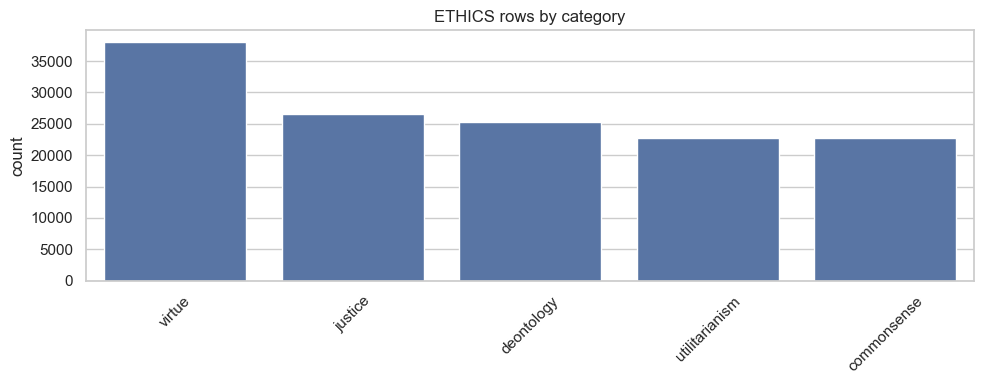

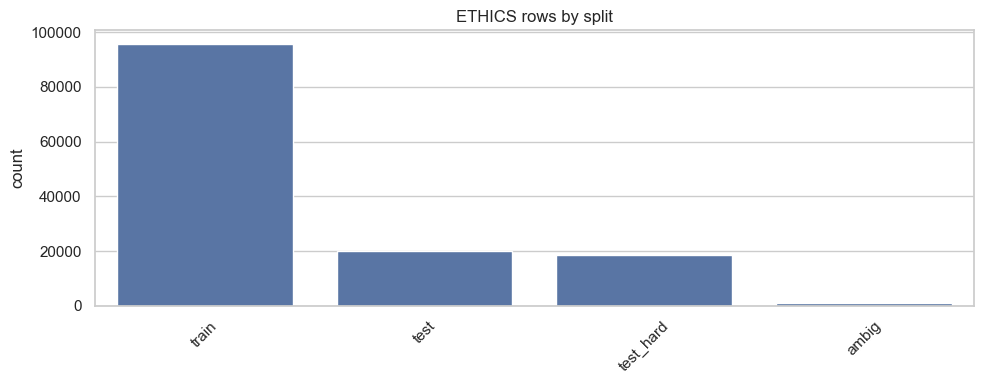

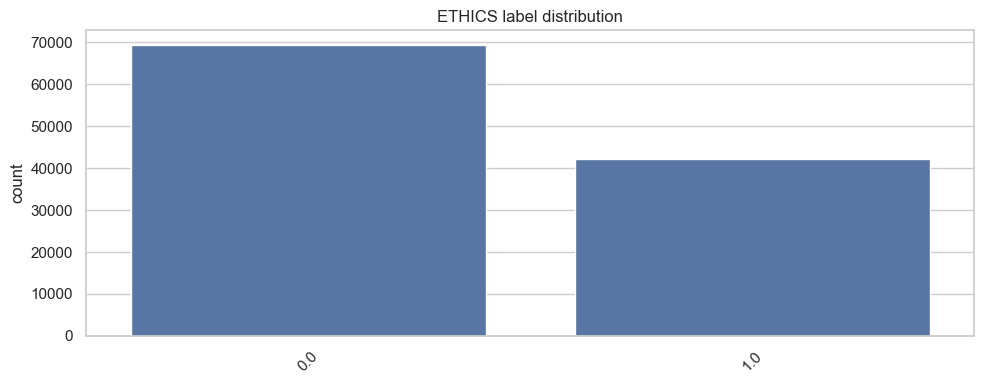

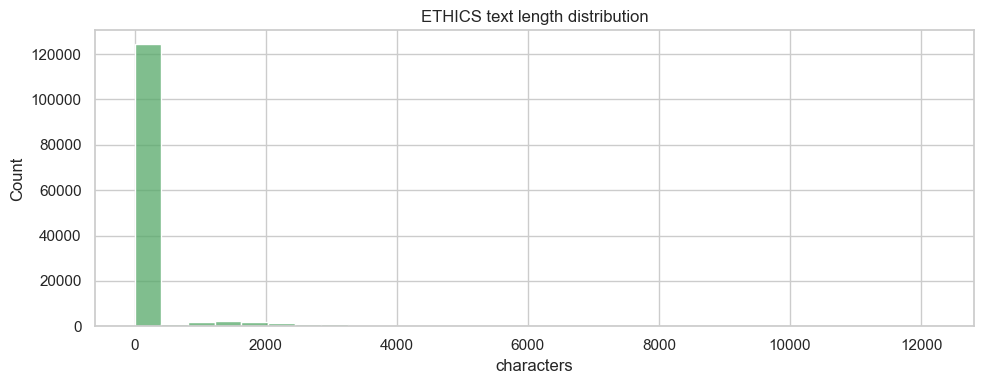

Duplicate text hashes with more than one occurrence: 7823


In [ ]:
# -----------------------------------------------------------------------------
# Cell Purpose: Extract the first usable text and label field from each raw row
# Why it matters:
# - ETHICS sub-tasks do not use a single consistent schema
# - Different files may store the usable text/label in different columns
# - This step converts heterogeneous raw rows into a consistent analysis table
# -----------------------------------------------------------------------------

def pick_first_value(row, candidates):
    """
    Return the first non-empty value found in a row from a list of candidate columns.

    Args:
        row (dict): One raw record as a dictionary.
        candidates (list[str]): Ordered list of possible column names.

    Returns:
        tuple[str, str]:
            - the selected column name
            - the cleaned string value from that column

    Behavior:
        - skips missing values
        - skips blank strings after stripping whitespace
        - returns ("", "") if no usable value is found

    Why this exists:
        ETHICS files vary across sub-tasks, so the usable text or label field
        is not always stored under the same column name.
    """
    for key in candidates:
        value = row.get(key)
        if pd.notna(value) and str(value).strip():
            return key, str(value).strip()
    return "", ""


# -----------------------------------------------------------------------------
# Build an analysis dataframe with harmonized text/label extraction
# -----------------------------------------------------------------------------
analysis_rows = []

# Convert the raw dataframe into row dictionaries so we can inspect each record
# and select the first usable text and label fields.
for row in raw_df.to_dict(orient="records"):

    # Identify the first usable text field for this row
    text_key, text_value = pick_first_value(row, TEXT_FIELDS)

    # Identify the first usable label field for this row
    label_key, label_value = pick_first_value(row, LABEL_FIELDS)

    # Store normalized row-level information for later diagnostics and cleaning
    analysis_rows.append({
        "category": row["category"],
        "task": row["task"],
        "split": row["split"],
        "source_file": row["source_file"],
        "text_field": text_key,   # which raw column supplied the text
        "label_field": label_key, # which raw column supplied the label
        "text": text_value,       # extracted usable text
        "label": label_value,     # extracted usable label
    })


# -----------------------------------------------------------------------------
# Convert extracted rows into a dataframe and add diagnostic features
# -----------------------------------------------------------------------------
analysis_df = pd.DataFrame(analysis_rows)

# Character length of extracted text
# Useful for profiling text variability and later modelling difficulty.
analysis_df["text_len"] = analysis_df["text"].str.len()

# Stable hash of extracted text
# Useful for duplicate detection across files and task splits.
analysis_df["text_hash"] = analysis_df["text"].map(
    lambda x: hashlib.sha1(x.encode("utf-8", errors="ignore")).hexdigest() if x else ""
)


# -----------------------------------------------------------------------------
# Preview extracted analysis table
# -----------------------------------------------------------------------------
# This confirms that raw rows have now been converted into a more consistent
# intermediate representation suitable for downstream quality checks.
display(analysis_df.head())


# -----------------------------------------------------------------------------
# Missingness and blank-content diagnostics
# -----------------------------------------------------------------------------
# First check: pandas-level nulls
# This tells us whether text/label are structurally missing.
display(analysis_df[["text", "label"]].isna().sum())

# Second check: blank strings
# This is often more important than null checks because some rows contain
# empty extracted content rather than actual NaN values.
display(
    analysis_df[["text", "label"]]
    .eq("")
    .sum()
    .rename("blank_count")
    .to_frame()
)


# -----------------------------------------------------------------------------
# Distribution diagnostics
# -----------------------------------------------------------------------------
# Category coverage: verifies that extraction preserved all ETHICS task families
plot_count(analysis_df["category"], "ETHICS rows by category")

# Split coverage: shows train/test/test_hard/ambig structure after extraction
plot_count(analysis_df["split"], "ETHICS rows by split")

# Label distribution: inspect only non-blank labels
plot_count(
    analysis_df.loc[analysis_df["label"] != "", "label"],
    "ETHICS label distribution"
)

# Text length distribution: helps profile the textual heterogeneity of ETHICS
plot_text_length(analysis_df["text"], "ETHICS text length distribution")


# -----------------------------------------------------------------------------
# Duplicate text audit
# -----------------------------------------------------------------------------
# Count how many distinct text hashes occur more than once.
# This is a simple but useful duplicate-detection check for repeated examples.
dup_counts = analysis_df.loc[
    analysis_df["text_hash"] != "", "text_hash"
].value_counts()

print("Duplicate text hashes with more than one occurrence:", int((dup_counts > 1).sum()))

In [ ]:
# =========================================================
# CELL PURPOSE:
# Construct final cleaned dataset, generate dataset summary,
# and identify duplicate text entries across sources.
#
# RUN IMPACT:
# Moderate — involves row-wise operations (apply) and groupby aggregations.
# =========================================================


# =========================================================
# STEP 1: CREATE CLEANED DATAFRAME
# ---------------------------------------------------------
# Select only relevant columns from analysis_df and create a working copy.
# This ensures downstream processing does not mutate the original dataframe.
# =========================================================
cleaned_df = analysis_df.loc[:, [
    "text", "label", "task", "split",
    "source_file", "category",
    "text_field", "label_field", "text_hash"
]].copy()


# =========================================================
# STEP 2: INSERT DATASET IDENTIFIER
# ---------------------------------------------------------
# Add a new column "dataset" to explicitly tag the origin
# of the data (useful when combining multiple datasets later).
# Inserted at index 2 for consistent column ordering.
# =========================================================
cleaned_df.insert(2, "dataset", "ethics")


# =========================================================
# STEP 3: CREATE METADATA COLUMN
# ---------------------------------------------------------
# Combine selected fields into a structured dictionary.
# This preserves traceability without cluttering the main schema.
#
# Metadata includes:
# - category: dataset sub-category
# - text_field: original column name used for text extraction
# - label_field: original column name used for label extraction
# - text_hash: unique hash identifier for duplicate detection
#
# Note:
# apply(axis=1) is used for row-wise dictionary construction.
# =========================================================
cleaned_df["metadata"] = cleaned_df.apply(
    lambda row: {
        "category": row["category"],
        "text_field": row["text_field"],
        "label_field": row["label_field"],
        "text_hash": row["text_hash"],
    },
    axis=1,
)


# =========================================================
# STEP 4: FINAL COLUMN REORDERING
# ---------------------------------------------------------
# Reduce dataframe to final schema for modelling/storage.
# This ensures a clean, standardised structure.
#
# Final schema:
# text | label | dataset | task | split | source_file | metadata
# =========================================================
cleaned_df = cleaned_df[[
    "text", "label", "dataset",
    "task", "split", "source_file", "metadata"
]]


# =========================================================
# STEP 5: DATASET QUALITY SUMMARY
# ---------------------------------------------------------
# Generate aggregated statistics grouped by:
# category, task, split, and source_file.
#
# Metrics computed:
# - rows: total number of records
# - missing_text: number of rows with empty text
# - missing_label: number of rows with empty labels
# - avg_text_len: average length of text entries
#
# Approach:
# - Create boolean flags for missing text/label
# - Use groupby + aggregation to compute metrics
# =========================================================
summary_df = (
    analysis_df
    .assign(
        has_text=analysis_df["text"] != "",
        has_label=analysis_df["label"] != ""
    )
    .groupby(["category", "task", "split", "source_file"], dropna=False)
    .agg(
        rows=("text", "size"),
        missing_text=("has_text", lambda s: int((~s).sum())),
        missing_label=("has_label", lambda s: int((~s).sum())),
        avg_text_len=("text_len", "mean"),
    )
    .reset_index()
)


# =========================================================
# STEP 6: DUPLICATE TEXT DETECTION
# ---------------------------------------------------------
# Identify duplicated text entries using text_hash.
#
# Process:
# 1. Filter out empty hashes (invalid/empty text)
# 2. Group by text_hash
# 3. Count occurrences
# 4. Track source_file locations for each duplicate
#
# Output:
# - occurrences: number of times the same text appears
# - locations: list of source files where it occurs
#
# Only retain entries where occurrences > 1
# =========================================================
dup_report_df = (
    analysis_df.loc[
        analysis_df["text_hash"] != "",
        ["text_hash", "category", "task", "split", "source_file", "text_field"]
    ]
    .groupby("text_hash")
    .agg(
        occurrences=("text_hash", "size"),
        locations=("source_file", lambda s: list(s)),
    )
    .reset_index()
)

# Keep only duplicated entries
dup_report_df = dup_report_df.loc[dup_report_df["occurrences"] > 1]


# =========================================================
# STEP 7: OUTPUT / VALIDATION
# ---------------------------------------------------------
# Display:
# - Shape of cleaned dataset
# - Sample rows from cleaned dataset
# - Summary statistics
# - Duplicate report
#
# This acts as a sanity check before downstream modelling.
# =========================================================
print("Cleaned shape:", cleaned_df.shape)

display(cleaned_df.head())
display(summary_df.head())
display(dup_report_df.head())

Cleaned shape: (135411, 7)


,text,label,dataset,task,split,source_file,metadata
0,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{'category': 'commonsense', 'text_field': '', 'label_field': '', 'text_hash': ''}"
1,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{'category': 'commonsense', 'text_field': '', 'label_field': '', 'text_hash': ''}"
2,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{'category': 'commonsense', 'text_field': '', 'label_field': '', 'text_hash': ''}"
3,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{'category': 'commonsense', 'text_field': '', 'label_field': '', 'text_hash': ''}"
4,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{'category': 'commonsense', 'text_field': '', 'label_field': '', 'text_hash': ''}"


,category,task,split,source_file,rows,missing_text,missing_label,avg_text_len
0,commonsense,cm,ambig,commonsense\cm_ambig.csv,994,994,994,0.000000
1,commonsense,cm,test,commonsense\cm_test.csv,3885,0,0,797.864607
2,commonsense,cm,test_hard,commonsense\cm_test_hard.csv,3964,0,0,960.821140
3,commonsense,cm,train,commonsense\cm_train.csv,13910,0,0,1023.451042
4,deontology,deontology,test,deontology\deontology_test.csv,3596,0,0,46.060067


,text_hash,occurrences,locations
8,0006480692a38601fbc9bc1e106c552d51d514dc,3,"[deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deontology_train.csv]"
22,000e7a901ffc7dc80bba4e24ad9419a29e55c7d5,4,"[deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deont..."
24,0010c538999e4b127b9f81e35016f56195db0d74,4,"[deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deont..."
39,00182da0007a23988c22b8556a6921ca4bc7c2e5,4,"[deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deont..."
53,001e242d6d042535cb25e5ada3170243986117a8,3,"[deontology\deontology_train.csv, deontology\deontology_train.csv, deontology\deontology_train.csv]"


In [ ]:
# =========================================================
# CELL PURPOSE:
# Persist cleaned dataset, summary statistics, and duplicate
# analysis outputs to disk in both JSONL and CSV formats.
#
# RUN IMPACT:
# I/O bound — depends on dataset size and disk write speed.
# =========================================================


# =========================================================
# STEP 1: CONDITIONAL SAVE CONTROL
# ---------------------------------------------------------
# Only write outputs if SAVE_OUTPUTS flag is enabled.
# This prevents accidental overwriting and allows preview mode.
# =========================================================
if SAVE_OUTPUTS:

    # =====================================================
    # STEP 2: SAVE CLEANED DATASET
    # -----------------------------------------------------
    # Export the final cleaned dataset in:
    # - JSONL format (for ML pipelines / streaming)
    # - CSV format (for inspection / Excel compatibility)
    #
    # Note:
    # orient="records" converts DataFrame rows into
    # list-of-dictionaries format.
    # =====================================================
    write_jsonl(
        OUT_DIR / "ethics.jsonl",
        cleaned_df.to_dict(orient="records")
    )
    write_csv(
        OUT_DIR / "ethics.csv",
        cleaned_df.to_dict(orient="records")
    )


    # =====================================================
    # STEP 3: SAVE DATASET SUMMARY
    # -----------------------------------------------------
    # Export aggregated statistics (missing values, lengths, etc.)
    # Useful for:
    # - data quality auditing
    # - reporting
    # =====================================================
    write_jsonl(
        OUT_DIR / "summary.jsonl",
        summary_df.to_dict(orient="records")
    )
    write_csv(
        OUT_DIR / "summary.csv",
        summary_df.to_dict(orient="records")
    )


    # =====================================================
    # STEP 4: SAVE DUPLICATE REPORT
    # -----------------------------------------------------
    # Export duplicate detection results based on text_hash.
    # Enables:
    # - identification of repeated samples
    # - debugging dataset leakage issues
    # =====================================================
    write_jsonl(
        OUT_DIR / "dup_report.jsonl",
        dup_report_df.to_dict(orient="records")
    )
    write_csv(
        OUT_DIR / "dup_report.csv",
        dup_report_df.to_dict(orient="records")
    )


    # =====================================================
    # STEP 5: GENERATE LABEL DISTRIBUTION SUMMARY
    # -----------------------------------------------------
    # Compute frequency of each label (excluding empty labels).
    #
    # Output format:
    # [{"labels": {label_1: count, label_2: count, ...}}]
    #
    # This structure is intentionally simple for:
    # - quick inspection
    # - compatibility with JSONL format
    # =====================================================
    label_summary = [
        {
            "labels": cleaned_df.loc[
                cleaned_df["label"] != "",
                "label"
            ].value_counts().to_dict()
        }
    ]


    # =====================================================
    # STEP 6: SAVE LABEL SUMMARY
    # -----------------------------------------------------
    # Export label distribution for downstream analysis
    # (e.g., class imbalance checks).
    # =====================================================
    write_jsonl(
        OUT_DIR / "label_summary.jsonl",
        label_summary
    )
    write_csv(
        OUT_DIR / "label_summary.csv",
        label_summary
    )


    # =====================================================
    # STEP 7: CONFIRMATION OUTPUT
    # -----------------------------------------------------
    # Provide user feedback indicating successful write.
    # =====================================================
    print("Wrote cleaned ETHICS outputs to", OUT_DIR)


# =========================================================
# STEP 8: PREVIEW MODE (NO WRITE)
# ---------------------------------------------------------
# If SAVE_OUTPUTS is False, skip writing and notify user.
# =========================================================
else:
    print(
        "Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files."
    )

Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files.
